In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from scipy.io import loadmat
import networkx as nx
from scipy.sparse import csr_matrix
import warnings
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
!cd /content/drive/MyDrive/vis

# Load Graph

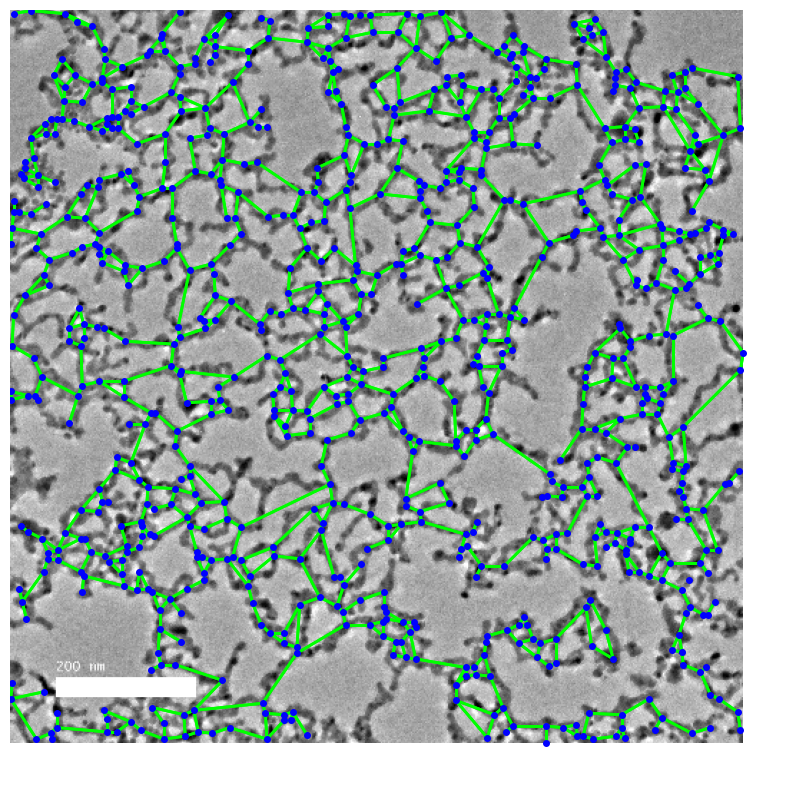

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load network data
network_path = '/content/drive/MyDrive/vis/20kX/sparse_matrices_20kX_new.npz'
network_data = np.load(network_path, allow_pickle=True)
edges = network_data['A'].item()  # Assuming A is a list of edges (i, j, weight)
rows, cols = edges.nonzero()

# Load node positions_of_nodes
positions_path = '/content/drive/MyDrive/vis/20kX_postion.npy'
positions = np.load(positions_path, allow_pickle=True)
positions[:, [0, 1]] = positions[:, [1, 0]]  # Swap columns to fit the plotting needs

# Get min and max coordinates for normalization
min_x = positions[:, 0].min()
max_x = positions[:, 0].max()
min_y = positions[:, 1].min()
max_y = positions[:, 1].max()

# Normalize function
def normalize(value, min_value, max_value):
    return (value - min_value) / (max_value - min_value)

# Load and resize original_image
canvas_image_path = '/content/drive/MyDrive/vis/20kX/Copy of 300kV 20kX  Pre-GIF 2045.tif'
raw_src = cv2.imread(canvas_image_path, cv2.IMREAD_GRAYSCALE)

h, w = raw_src.shape
scalefactor = 512 / max(w, h)
swidth = int(scalefactor * w)
sheight = int(scalefactor * h)
dsize = (swidth, sheight)
canvas_image_gray = cv2.resize(raw_src, dsize)

canvas_height, canvas_width = canvas_image_gray.shape

# Normalize and scale positions_of_nodes
scaled_positions = np.zeros_like(positions)
scaled_positions[:, 0] = normalize(positions[:, 0], min_x, max_x) * canvas_width
scaled_positions[:, 1] = normalize(positions[:, 1], min_y, max_y) * canvas_height

# Convert positions_of_nodes to a dictionary for easier access
position_dict = {i: pos for i, pos in enumerate(scaled_positions)}

# Plot original_image and network
plt.figure(figsize=(10, 10))
plt.imshow(canvas_image_gray, cmap='gray')

# Plot edges
for s, e in zip(rows, cols):
    if s in position_dict and e in position_dict:
        x1, y1 = position_dict[s]
        x2, y2 = position_dict[e]
        plt.plot([x1, x2], [y1, y2], color='lime', linewidth=2)

# Plot nodes
for (x, y) in scaled_positions:
    plt.plot(x, y, 'bo', markersize=4)

plt.axis('off')
plt.show()

# Calculation on the probabilty distribuition on the Degree, Angles _P(Angle|Degree)_, Lengths _P(Length|Degree)_

In [ ]:
import random
import math
from collections import defaultdict, deque

DEBUG = True

## Conditional Probabilites on degrees (degrees|degress)

In [ ]:
# In Degree
in_degree_count = defaultdict(int)
for start, end in zip(rows, cols):
    in_degree_count[start] += 1
in_degree_count = {node: degree for node, degree in in_degree_count.items() if degree > 0}

# Group nodes by degree
nodes_by_degree = defaultdict(list)
for node, degree in in_degree_count.items():
    nodes_by_degree[degree].append(node)

# Calculate degree probabilities
total_nodes = len(in_degree_count)
degree_probabilities = {degree: len(nodes) / total_nodes for degree, nodes in nodes_by_degree.items()}

# Adjacency Dictionary
adjacency_dict = defaultdict(set)
for start, end in zip(rows, cols):
    adjacency_dict[start].add(end)
    adjacency_dict[end].add(start)

# Mapping from each degree to the degrees of its connected vertices
degree_neighbors_map = defaultdict(list)
for node, neighbors in adjacency_dict.items():
    node_degree = in_degree_count[node]
    neighbor_degrees = [in_degree_count[neighbor] for neighbor in neighbors]
    degree_neighbors_map[node_degree].extend(neighbor_degrees)

# Calculate degree transition probabilities
degree_transition_probs = {}
for degree, neighbor_degrees in degree_neighbors_map.items():
    degree_distribution = defaultdict(int)
    for neighbor_degree in neighbor_degrees:
        degree_distribution[neighbor_degree] += 1
    total_neighbors = sum(degree_distribution.values())
    degree_transition_probs[degree] = {k: v / total_neighbors for k, v in degree_distribution.items()}

# Degree Edge Lengths and Angles Calculation (Existing Code)
edge_lengths_by_degree = defaultdict(list)
angles_by_degree = defaultdict(list)

def calculate_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

normalized_positions = {node: np.array(position, dtype=np.float64) for node, position in position_dict.items()}

for node, node_pos in normalized_positions.items():
    if node not in in_degree_count:
        continue

    neighbors = list(adjacency_dict[node])
    lengths = [calculate_distance(node_pos, normalized_positions[n]) for n in neighbors if n in normalized_positions]
    node_degree = in_degree_count[node]
    if node_degree > 0:
        edge_lengths_by_degree[node_degree].extend(lengths)

    if len(neighbors) > 1:
        # Convert neighbors to polar coordinates (angle relative to the node)
        polar_coords = [(n, np.arctan2(np.float64(normalized_positions[n][1] - node_pos[1]), np.float64(normalized_positions[n][0] - node_pos[0])))
                        for n in neighbors if n in normalized_positions]

        # Sort neighbors by their polar angle
        polar_coords.sort(key=lambda x: x[1])

        # Calculate angles between adjacent edges
        angles = []
        for i in range(len(polar_coords)):
            angle_diff = (polar_coords[(i + 1) % len(polar_coords)][1] - polar_coords[i][1]) * (180 / np.pi)
            if angle_diff < 0:
                angle_diff += 360
            angles.append(round(angle_diff, 0))

        if node_degree > 0:
            angles_by_degree[node_degree].extend(angles)

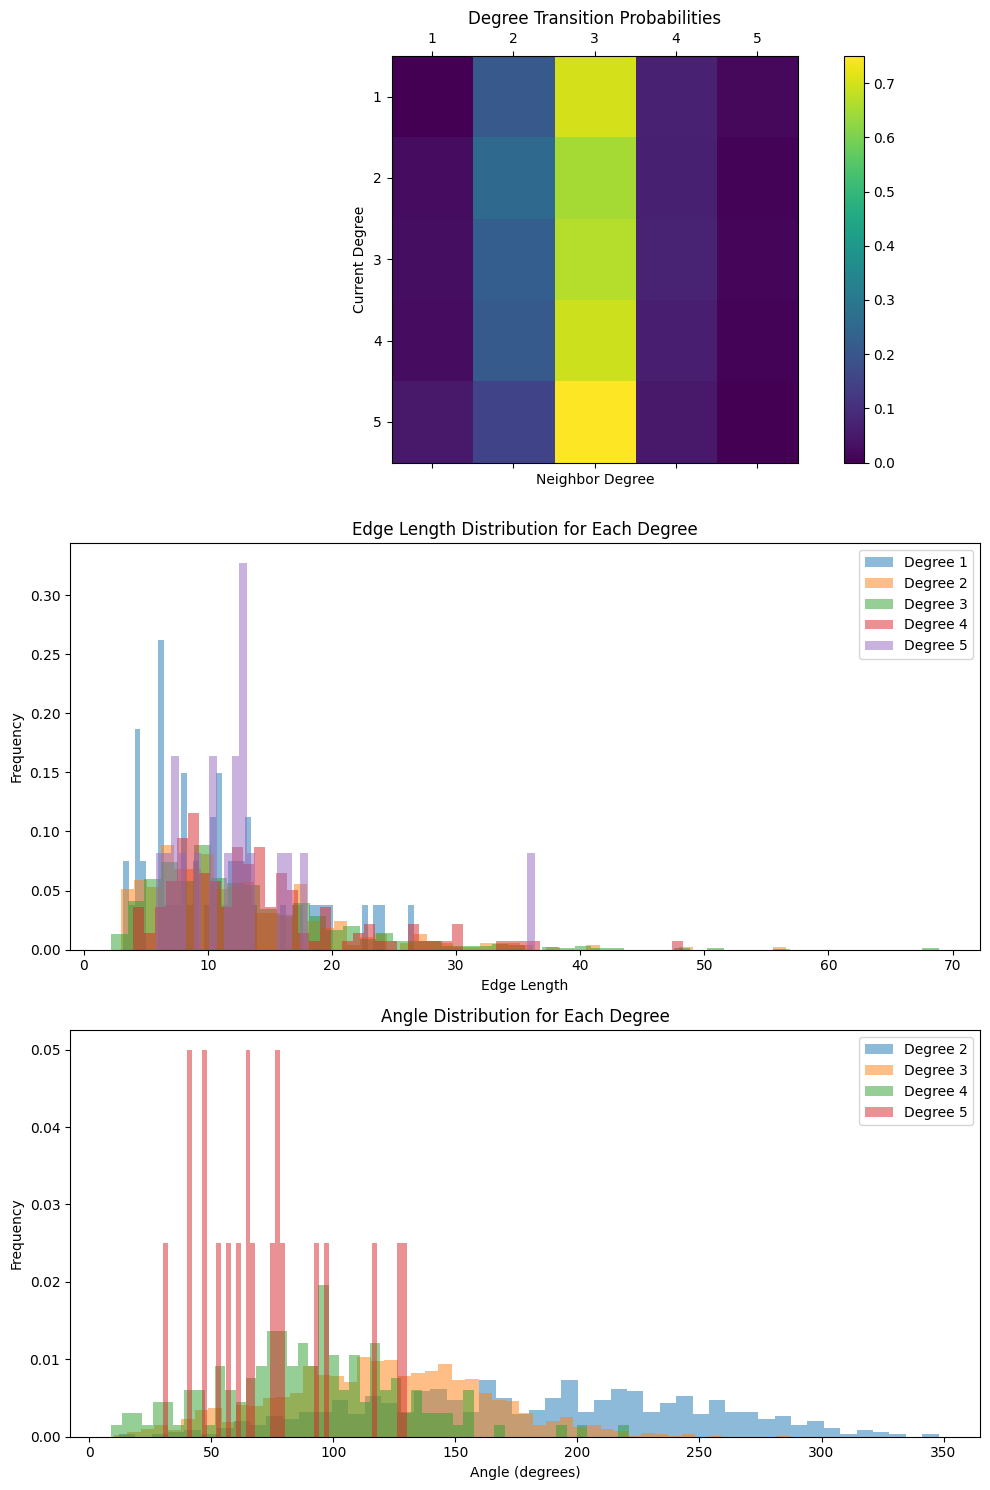

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

degrees = sorted(degree_transition_probs.keys())
transition_matrix = np.zeros((len(degrees), len(degrees)))

for i, degree in enumerate(degrees):
    for j, neighbor_degree in enumerate(degrees):
        transition_matrix[i, j] = degree_transition_probs[degree].get(neighbor_degree, 0)

cax = axs[0].matshow(transition_matrix, cmap='viridis')
fig.colorbar(cax, ax=axs[0])
axs[0].set_xticks(np.arange(len(degrees)))
axs[0].set_yticks(np.arange(len(degrees)))
axs[0].set_xticklabels(degrees)
axs[0].set_yticklabels(degrees)
axs[0].set_xlabel('Neighbor Degree')
axs[0].set_ylabel('Current Degree')
axs[0].set_title('Degree Transition Probabilities')

# Generate and plot random samples for edge lengths
for degree in sorted(edge_lengths_by_degree.keys()):
    if len(edge_lengths_by_degree[degree]) > 0:
        random_lengths = edge_lengths_by_degree[degree]

        axs[1].hist(random_lengths, bins=50, density=True, alpha=0.5, label=f'Degree {degree}')
        axs[1].set_xlabel('Edge Length')
        axs[1].set_ylabel('Frequency')
        axs[1].set_title('Edge Length Distribution for Each Degree')
        axs[1].legend()

# Generate and plot random samples for angles
for degree in sorted(angles_by_degree.keys()):
    if len(angles_by_degree[degree]) > 0:
        random_angles = angles_by_degree[degree]

        axs[2].hist(random_angles, bins=50, density=True, alpha=0.5, label=f'Degree {degree}')
        axs[2].set_xlabel('Angle (degrees)')
        axs[2].set_ylabel('Frequency')
        axs[2].set_title('Angle Distribution for Each Degree')
        axs[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
from datetime import datetime
import time

In [ ]:
def timer(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"\n{func.__name__} time taken: {end - start} seconds")
        return result
    return wrapper

In [ ]:
class GraphNode:
    degree_distribution = []
    degree_transition_probs = {}
    degree_angles = {}
    degree_edge_lengths = {}
    node_grid = defaultdict(set)
    edge_grid = defaultdict(set)
    grid_size = 13
    aborted_edge = 0
    merged_edge = 0
    id_counter = 0

    enable_check_intersection = True
    enable_merge_nodes = True
    enable_clockwise = True
    enable_degree_transition_probs = True
    enable_merge_edges = True

    def __init__(self, position, *, parent=None, parent_angle=None):
        '''
        PRE: param parent and parent_angle must be provided together or not at all.
        POST: The first children of a non-root node is the parent.
        '''
        self.id = GraphNode.id_counter
        GraphNode.id_counter += 1
        self.position = position
        self.clockwise = random.choice([True, False]) if GraphNode.enable_clockwise else True
        self.parent = parent
        self.children = []

        if parent is not None and parent_angle is not None:  # Non-root Node
            self.degree = self.choose_degree_based_on_parent(parent.degree) if GraphNode.enable_degree_transition_probs else random.choice(GraphNode.degree_distribution)
            self.base_angle = (parent_angle + 180) % 360
            self.add_child(self.parent)
        elif parent is None and parent_angle is None:  # Root Node
            self.degree = random.choice(GraphNode.degree_distribution)
            self.base_angle = random.uniform(0, 360)
            self.initialize_root_node()
        else:
            raise ValueError("Both parent and parent_angle must be provided together or not at all.")

    def choose_degree_based_on_parent(self, parent_degree):
        degrees = list(GraphNode.degree_transition_probs[parent_degree].keys())
        probabilities = list(GraphNode.degree_transition_probs[parent_degree].values())
        return np.random.choice(degrees, p=probabilities)

    def initialize_root_node(self):
        length = random.choice(GraphNode.degree_edge_lengths[self.degree])
        child_position = self.polar_to_cartesian([length], [self.base_angle])[0]
        child = GraphNode(child_position, parent=self, parent_angle=self.base_angle)
        edge = (self.position, child_position)
        self.add_child(child)
        self.add_to_grid(self.position)
        self.add_to_grid(child.position)
        self.add_edge_to_grid(edge)

    def add_child(self, child):
        if len(self.children) >= self.degree:
            raise Exception(f"Node {self} cannot have more than {self.degree} children, current children {self.children}")
        self.children.append(child)
        self.add_to_grid(child.position)

    def add_to_grid(self, position):
        key = self.spatial_hash(position)
        GraphNode.node_grid[key].add(self)
        if len(GraphNode.node_grid[key]) > 1000:
            print("Unusual length of nodes collision chain")

    def add_edge_to_grid(self, edge):
        keys = self.edge_spatial_hash(*edge)
        for key in keys:
            GraphNode.edge_grid[key].add(edge)
            if len(GraphNode.edge_grid[key]) > 1000:
                print("Unusual length of edges collision chain")

    def generate_children(self) -> bool:
        if len(self.children) > 1 or self.degree == 1: # Skip visited nodes or Endpoint has no other child
            return False
        angles, lengths = self.generate_angles_and_lengths()
        children_positions = self.polar_to_cartesian(lengths, angles)
        assert len(children_positions) == self.degree - 1

        for child_position, angle in zip(children_positions, angles):
            if GraphNode.enable_merge_edges and self.find_close_edge(child_position):
                GraphNode.aborted_edge += 1
                continue
            close_node = self.get_closest_valid_node(child_position)
            new_edge = (self.position, child_position)
            if GraphNode.enable_merge_nodes and close_node is not None:
                new_edge = (self.position, close_node.position)
                if not self.check_intersection(new_edge):
                    self.add_child(close_node)
                    self.add_edge_to_grid(new_edge)
                    GraphNode.merged_edge += 1
                else:
                    GraphNode.aborted_edge += 1
            else:
                if not self.check_intersection(new_edge):
                    child_node = GraphNode(child_position, parent=self, parent_angle=angle)
                    self.add_child(child_node)
                    self.add_edge_to_grid(new_edge)
                    self.add_to_grid(child_node.position)
                else:
                    GraphNode.aborted_edge += 1
        return True

    def get_closest_valid_node(self, position):
        close_nodes_with_distances = self.find_close_node(position)
        if close_nodes_with_distances:
            return min(close_nodes_with_distances, key=lambda x: x[1])[0]
        return None

    def find_close_node(self, position, threshold=None):
        threshold = threshold or GraphNode.grid_size
        key = self.spatial_hash(position)
        neighboring_keys = [
            (key[0] + dx, key[1] + dy)
            for dx in range(-1, 2)
            for dy in range(-1, 2)
        ]
        close_nodes_with_distances = []
        for neighbor_key in neighboring_keys:
            for node in GraphNode.node_grid[neighbor_key]:
                if node != self and node not in self.children:
                    distance = np.linalg.norm(np.array(node.position) - np.array(position))
                    if distance < threshold:
                        close_nodes_with_distances.append((node, distance))
        return close_nodes_with_distances

    def generate_angles_and_lengths(self):
        if self.degree == 1:
            return [], []
        angles = random.choices(GraphNode.degree_angles[self.degree], k=self.degree-1)
        angles = np.cumsum(angles) if self.clockwise else np.cumsum([-angle for angle in angles])
        angles = (angles + self.base_angle).tolist()
        lengths = random.choices(GraphNode.degree_edge_lengths[self.degree], k=self.degree-1)
        return angles, lengths

    def polar_to_cartesian(self, lengths, angles):
        x, y = self.position
        cartesian_coords = []
        for length, angle in zip(lengths, angles):
            angle_rad = np.deg2rad(angle)
            new_x = x + length * np.cos(angle_rad)
            new_y = y + length * np.sin(angle_rad)
            cartesian_coords.append((new_x, new_y))
        return cartesian_coords

    def find_close_edge(self, position, threshold=None):
        key = self.spatial_hash(position)
        neighboring_keys = [
            (key[0] + dx, key[1] + dy)
            for dx in range(-1, 2)
            for dy in range(-1, 2)
        ]
        for neighbor_key in neighboring_keys:
            for edge in GraphNode.edge_grid[neighbor_key]:
                if self.is_non_sibling_edge(edge, position, threshold):
                    return True
        return False

    def is_non_sibling_edge(self, edge, position, threshold=None):
        threshold = threshold or GraphNode.grid_size*.6
        if self.parent and (self.parent.position in edge or self.position in edge):
            return False  # Skip edges from the same parent
        p1, p2 = edge
        distances = [
            np.linalg.norm(np.array(position) - np.array(p1)),
            np.linalg.norm(np.array(position) - np.array(p2))
        ]
        return any(distance < threshold for distance in distances)

    def check_intersection(self, new_edge):
        if not GraphNode.enable_check_intersection:
            return False
        keys = self.edge_spatial_hash(*new_edge)
        for key in keys:
            for edge in GraphNode.edge_grid[key]:
                # if new_edge[0] == edge[0] or new_edge[0] == edge[1] or new_edge[1] == edge[0] or new_edge[1] == edge[1]:
                if new_edge[0] in edge or new_edge[1] in edge:
                    continue  # Skip edges with the same endpoint
                if GraphNode.do_intersect(new_edge[0], new_edge[1], edge[0], edge[1]):
                    return True
        return False

    @staticmethod
    def spatial_hash(position, grid_size=None):
        grid_size = grid_size or GraphNode.grid_size
        return (int(position[0] // grid_size), int(position[1] // grid_size))

    @staticmethod
    def edge_spatial_hash(p1, p2, grid_size=None):
        grid_size = grid_size or GraphNode.grid_size
        x_min, x_max = sorted([p1[0], p2[0]])
        y_min, y_max = sorted([p1[1], p2[1]])
        keys = {(int(x // grid_size), int(y // grid_size))
                for x in np.arange(x_min, x_max + grid_size, grid_size)
                for y in np.arange(y_min, y_max + grid_size, grid_size)}
        return keys

    @staticmethod
    def do_intersect(p1, q1, p2, q2):
        def orientation(p, q, r):
            val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
            return 0 if val == 0 else 1 if val > 0 else 2

        def on_segment(p, q, r):
            return min(p[0], r[0]) <= q[0] <= max(p[0], r[0]) and min(p[1], r[1]) <= q[1] <= max(p[1], r[1])

        o1, o2, o3, o4 = orientation(p1, q1, p2), orientation(p1, q1, q2), orientation(p2, q2, p1), orientation(p2, q2, q1)
        return (o1 != o2 and o3 != o4) or (o1 == 0 and on_segment(p1, p2, q1)) or (o2 == 0 and on_segment(p1, q2, q1)) or (o3 == 0 and on_segment(p2, p1, q2)) or (o4 == 0 and on_segment(p2, q1, q2))

    @staticmethod
    def reset(default_grid_size=13):
        GraphNode.node_grid = defaultdict(set)
        GraphNode.edge_grid = defaultdict(set)
        GraphNode.aborted_edge = 0
        GraphNode.merged_edge = 0
        GraphNode.id_counter = 0
        GraphNode.grid_size = default_grid_size

    def __repr__(self):
        return f"Node (Id. {self.id})"

    def __str__(self):
        return f"Node (Id. {self.id})"

    # def __eq__(self, other):
    #     equ_x = round(self.position[0], 0) == round(self.position[0], 0)
    #     equ_y = round(self.position[1], 0) == round(self.position[1], 0)
    #     equ_pos = equ_x and equ_y
    #     equ_i = self.id == other.id
    #     if equ_pos and not equ_i:
    #         print(f"Two Nodes are too closed: {self} and {other}")
    #     return equ_pos and equ_i

GraphNode.degree_distribution = [degree for degree in in_degree_count.values() if degree > 0]
GraphNode.degree_transition_probs = degree_transition_probs
GraphNode.degree_angles = angles_by_degree
GraphNode.degree_edge_lengths = edge_lengths_by_degree

In [ ]:
@timer
def generate_network(frame_size=1000, grid_size=26, conditional_degree=True):
    # Position frame [[left, right], [top, bottom]]
    position_frame = [[-frame_size, frame_size], [-frame_size, frame_size]]

    GraphNode.reset(grid_size)
    GraphNode.enable_degree_transition_probs = conditional_degree

    root = GraphNode((0, 0))
    nodes = set([root])
    edges = set([])

    def is_within_frame(position, frame):
        x, y = position
        return frame[0][0] <= x <= frame[0][1] and frame[1][0] <= y <= frame[1][1]

    def generate_graph_bfs(root, frame):
        queue = deque([root])
        while queue:
            if len(nodes) >= 1e5:
                print(f"Unusual amount of nodes, more than {len(nodes)}, aborting...")
                break

            node = queue.popleft()
            if not is_within_frame(node.position, frame):
                continue

            if node.generate_children():
                for child_node in node.children:
                    if child_node == node:
                        continue  # Skip the parent node
                    nodes.add(child_node)
                    edges.add((node.position, child_node.position))
                    queue.append(child_node) # Since merging, inf loop warning

    generate_graph_bfs(root, position_frame)
    return nodes, edges

In [ ]:
@timer
def plot_network(nodes, edges, regen=False, regen_factor:float=1, node_only=False, save=False, graph_name="", background=False, conditional_degree=True):
    if regen:
        while (len(nodes)) <= 100:
            all_edge_lengths = [length for lengths in GraphNode.degree_edge_lengths.values() for length in lengths]
            mean_length = np.mean(all_edge_lengths)
            nodes, edges = generate_network(500, int(round(regen_factor * mean_length, 0)), conditional_degree)
            if len(nodes) > 100:
                print(f"Total nodes during generating: {len(nodes)}, edges: {len(edges)}, aborted: {GraphNode.aborted_edge}, merged: {GraphNode.merged_edge}")

    if node_only:
        return nodes, edges, None, None, None

    # Plot original_image and network
    fig, ax = plt.subplots(figsize=(10, 10))
    if background:
        # Load and resize original_image
        canvas_image_path = '/content/drive/MyDrive/vis/20kX/Copy of 300kV 20kX  Pre-GIF 2045.tif'
        raw_src = cv2.imread(canvas_image_path, cv2.IMREAD_GRAYSCALE)
        if raw_src is None:
            raise FileNotFoundError(f"Image file not found: {canvas_image_path}")

        h, w = raw_src.shape
        scalefactor = 512 / max(w, h)
        swidth = int(scalefactor * w)
        sheight = int(scalefactor * h)
        dsize = (swidth, sheight)
        canvas_image_gray = cv2.resize(raw_src, dsize)
        canvas_height, canvas_width = canvas_image_gray.shape

        ax.imshow(canvas_image_gray, cmap='gray', extent=[0, canvas_width, 0, canvas_height])

    for edge in edges:
        x_values = [edge[0][0], edge[1][0]]
        y_values = [edge[0][1], edge[1][1]]
        ax.plot(x_values, y_values, 'b-', linewidth=0.5, zorder=2)

    for node in nodes:
        ax.plot(node.position[0], node.position[1], 'ro', markersize=1.5, zorder=2)

    xs = [node.position[0] for node in nodes]
    ys = [node.position[1] for node in nodes]

    center_x = sum(xs) / len(xs)
    center_y = sum(ys) / len(ys)
    range_x = max(xs) - min(xs)
    range_y = max(ys) - min(ys)

    factor = 0.96
    # min_range = min(range_x, range_y) * factor
    min_range = 500

    DEBUG = False
    if not DEBUG:
        ax.set_xlim(center_x - min_range / 2, center_x + min_range / 2)
        ax.set_ylim(center_y - min_range / 2, center_y + min_range / 2)

    def generate_adjacency_matrix(nodes, edges):
        node_positions = {node.position: idx for idx, node in enumerate(nodes)}
        size = len(nodes)
        adj_matrix = np.zeros((size, size), dtype=int)

        for edge in edges:
            idx1 = node_positions[edge[0]]
            idx2 = node_positions[edge[1]]
            adj_matrix[idx1, idx2] = 1
            adj_matrix[idx2, idx1] = 1  # Assuming undirected original_graph

        return adj_matrix

    # Determine nodes and edges within the frame
    val_ns = {node for node in nodes
              if center_x - min_range / 2 <= node.position[0] <= center_x + min_range / 2 and
              center_y - min_range / 2 <= node.position[1] <= center_y + min_range / 2}
    val_es = {edge for edge in edges
              if center_x - min_range / 2 <= edge[0][0] <= center_x + min_range / 2 and
              center_y - min_range / 2 <= edge[0][1] <= center_y + min_range / 2 and
              center_x - min_range / 2 <= edge[1][0] <= center_x + min_range / 2 and
              center_y - min_range / 2 <= edge[1][1] <= center_y + min_range / 2}
    adj_matrix = generate_adjacency_matrix(val_ns, val_es)

    # Add a scale ruler with a background block
    scale_length = 100  # Adjust as needed
    scale_x_start = center_x - min_range / 2 + 50
    scale_x_end = scale_x_start + scale_length
    scale_y = center_y - min_range / 2 + 50

    block_height = 20
    block_padding = 5
    background_rect = plt.Rectangle((scale_x_start - block_padding, scale_y - block_padding - block_height / 2),
                                    scale_length + 2 * block_padding,
                                    block_height + 2 * block_padding,
                                    facecolor='white', edgecolor='none', zorder=3)
    ax.add_patch(background_rect)
    ax.plot([scale_x_start, scale_x_end], [scale_y, scale_y], 'k-', linewidth=2, zorder=3)
    ax.text(scale_x_start + scale_length / 2, scale_y + block_padding, f'{scale_length}',
            ha='center', fontsize=12, color='black', zorder=4,
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5'))

    # Remove outer lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.title('Generated Graph Based on Probability Distributions')
    if save:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f'{graph_name}_graph_{timestamp}.png'
        plt.savefig(filename, dpi=600)
        print(f"Graph saved as {filename}")
    else:
        plt.show()

    # Any parts of a edge being out of the frame will be skipped
    print(f"Total Nodes in the Graph: {len(val_ns)}, edges: {len(val_es)}")
    return nodes, edges, val_ns, val_es, adj_matrix

In [ ]:
# Valid vertices, edges, and adjacency matrix will only be known when plotting
_, _, val_n, val_e, adj = plot_network([], [], regen=True, regen_factor=1)

### Filtered Graph

In [ ]:
def filter_graph(adj_matrix, max_degree=5):
    G = nx.from_numpy_array(adj_matrix)
    nodes_to_remove = [node for node, degree in dict(G.degree()).items() if degree > max_degree or degree == 0]
    G.remove_nodes_from(nodes_to_remove)
    new_adj_matrix = nx.to_numpy_array(G)
    return G, new_adj_matrix

# Remove nodes with degree greater than 5 and standalone nodes
G_filtered, adj_filtered = filter_graph(adj)

# Calculate degree distribution for the filtered original_graph
degrees_filtered = dict(G_filtered.degree())
unique_degrees_filtered, counts_filtered = np.unique(list(degrees_filtered.values()), return_counts=True)
degree_distribution_filtered = dict(zip(unique_degrees_filtered, counts_filtered / sum(counts_filtered)))

print("In Filtered Graph the distribution is:")
for k in sorted(degree_distribution_filtered.keys()):
    ratio = round(degree_distribution_filtered[k], 3)
    print(f"- {k}: {ratio}")

# Calculate the mean number of nodes and edges in the filtered original_graph
mean_num_nodes_filtered = G_filtered.number_of_nodes()
mean_num_edges_filtered = G_filtered.number_of_edges()
print(f"Mean number of nodes in Filtered Graph: {mean_num_nodes_filtered}")
print(f"Mean number of edges in Filtered Graph: {mean_num_edges_filtered}")

# Calculate average closeness centrality for the filtered original_graph
closeness_centrality_filtered = nx.closeness_centrality(G_filtered)
avg_closeness_centrality_filtered = np.mean(list(closeness_centrality_filtered.values()))
print(f"Average closeness centrality in Filtered Graph: {avg_closeness_centrality_filtered}")

plt.figure(figsize=(10, 10))

positions = {i: (node.position[0], node.position[1]) for i, node in enumerate(val_n)}
filtered_nodes = list(G_filtered.nodes)
filtered_edges = list(G_filtered.edges)

for s, e in filtered_edges:
    if s in positions and e in positions:
        x1, y1 = positions[s]
        x2, y2 = positions[e]
        plt.plot([x1, x2], [y1, y2], 'b-', linewidth=0.5, zorder=2)

for node in filtered_nodes:
    if node in positions:
        x, y = positions[node]
        plt.plot(x, y, 'ro', markersize=1.5, zorder=2)

plt.axis('off')
plt.title('Filtered Graph with Degree <= 5')
plt.show()

### Analyse Graph

In [ ]:
# Run 10 experiments
adj_conds = []
adj_plains = []
val_ns_conds = []
val_es_conds = []
val_ns_plains = []
val_es_plains = []

for i in range(10):
    _, _, val_n_cond, val_e_cond, adj_cond = plot_network([], [], regen=True, regen_factor=1, conditional_degree=True)
    _, _, val_n_plain, val_e_plain, adj_plain = plot_network([], [], regen=True, regen_factor=1, conditional_degree=False)

    adj_conds.append(adj_cond)
    adj_plains.append(adj_plain)
    val_ns_conds.append(len(val_n_cond))
    val_es_conds.append(len(val_e_cond))
    val_ns_plains.append(len(val_n_plain))
    val_es_plains.append(len(val_e_plain))

In [ ]:
# Calculate degree distributions
def calculate_mean_degree_distribution(adjacency_matrices):
    all_degrees = []
    for adj in adjacency_matrices:
        degrees = np.sum(adj, axis=1)
        all_degrees.extend(degrees)

    unique, counts = np.unique(all_degrees, return_counts=True)
    degree_distribution = dict(zip(unique, counts / len(adjacency_matrices)))

    return degree_distribution

mean_degree_dist_cond = calculate_mean_degree_distribution(adj_conds)
mean_degree_dist_plain = calculate_mean_degree_distribution(adj_plains)

# Print the degree distribution for art_graph_deg_distribution in Markdown format
def print_degree_distribution(degree_distribution, title):
    total_nodes = sum(degree_distribution.values())
    print(f"{title}")
    for k in sorted(degree_distribution.keys()):
        ratio = round(degree_distribution[k] / total_nodes, 3)
        print(f"- {k}: {ratio}")

print_degree_distribution(mean_degree_dist_cond, "In Conditional Degree Graph the distribution is:")
print_degree_distribution(mean_degree_dist_plain, "In Plain Graph the distribution is:")

# Print the mean number of nodes and edges
mean_val_ns_cond = np.mean(val_ns_conds)
mean_val_es_cond = np.mean(val_es_conds)
mean_val_ns_plain = np.mean(val_ns_plains)
mean_val_es_plain = np.mean(val_es_plains)

print(f"Mean number of nodes in Conditional Degree Graph: {mean_val_ns_cond}")
print(f"Mean number of edges in Conditional Degree Graph: {mean_val_es_cond}")

print(f"Mean number of nodes in Plain Graph: {mean_val_ns_plain}")
print(f"Mean number of edges in Plain Graph: {mean_val_es_plain}")